# Tarantino: How Does He Build Intensity?

This notebook analyzes the corrected seven-film Tarantino dataset.

The analysis looks at:

1. Normalized profanity and death rates
2. Where events occur throughout each movie
3. How profanity and deaths change through each movie
4. The relationship between profanity and deaths
5. A standardized "intensity fingerprint" for each film

The event data and movie runtime data are loaded in the **first code cell** so
all subsequent cells can be run independently or sequentially.

## Setup and data preparation

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Load the corrected seven-film datasets.
events = pd.read_csv("tarantino.csv")
movies = pd.read_csv("tarantino_omdb.csv")

# Rename the movie metadata columns used in the analysis.
movies = movies.rename(
    columns={
        "Title": "movie",
        "Runtime (minutes)": "runtime",
    }
)

# Convert runtime to a numeric value.
movies["runtime"] = (
    movies["runtime"]
    .astype(str)
    .str.extract(r"(\d+)")[0]
    .astype(float)
)

# Standardize the event type.
events["type"] = events["type"].str.lower()

# Keep the movies represented in the corrected movie metadata.
movie_order = movies["movie"].tolist()

events = events[
    events["movie"].isin(movie_order)
].copy()

# Directory for chart output.
out = Path("tarantino_charts_corrected")
out.mkdir(exist_ok=True)

# Quick checks.
print("Movies:")
print(movie_order)

print("\nNumber of events:", len(events))
print("\nEvents by movie:")
print(events["movie"].value_counts().reindex(movie_order))

print("\nData loaded successfully.")


Movies:
['Reservoir Dogs', 'Pulp Fiction', 'Jackie Brown', 'Kill Bill: Vol. 1', 'Kill Bill: Vol. 2', 'Inglorious Basterds', 'Django Unchained']

Number of events: 1894

Events by movie:
movie
Reservoir Dogs         431
Pulp Fiction           476
Jackie Brown           372
Kill Bill: Vol. 1      120
Kill Bill: Vol. 2       80
Inglorious Basterds    106
Django Unchained       309
Name: count, dtype: int64

Data loaded successfully.


## Summary metrics

In [5]:
summary = (
    events
    .groupby(["movie", "type"])
    .size()
    .unstack(fill_value=0)
    .reindex(movie_order)
    .fillna(0)
)

summary = summary.join(
    movies.set_index("movie")["runtime"]
)

summary["profanity_per_min"] = (
    summary["word"] / summary["runtime"]
)

summary["deaths_per_min"] = (
    summary["death"] / summary["runtime"]
)

summary


,death,word,runtime,profanity_per_min,deaths_per_min
movie,,,,,
Reservoir Dogs,10,421,99.0,4.252525,0.101010
Pulp Fiction,7,469,154.0,3.045455,0.045455
Jackie Brown,4,368,154.0,2.389610,0.025974
Kill Bill: Vol. 1,63,57,111.0,0.513514,0.567568
Kill Bill: Vol. 2,11,69,137.0,0.503650,0.080292
Inglorious Basterds,48,58,153.0,0.379085,0.313725
Django Unchained,47,262,165.0,1.587879,0.284848


## 1. Normalized intensity by movie

Normalizing by runtime prevents longer movies from automatically appearing more intense simply because they contain more minutes of content.

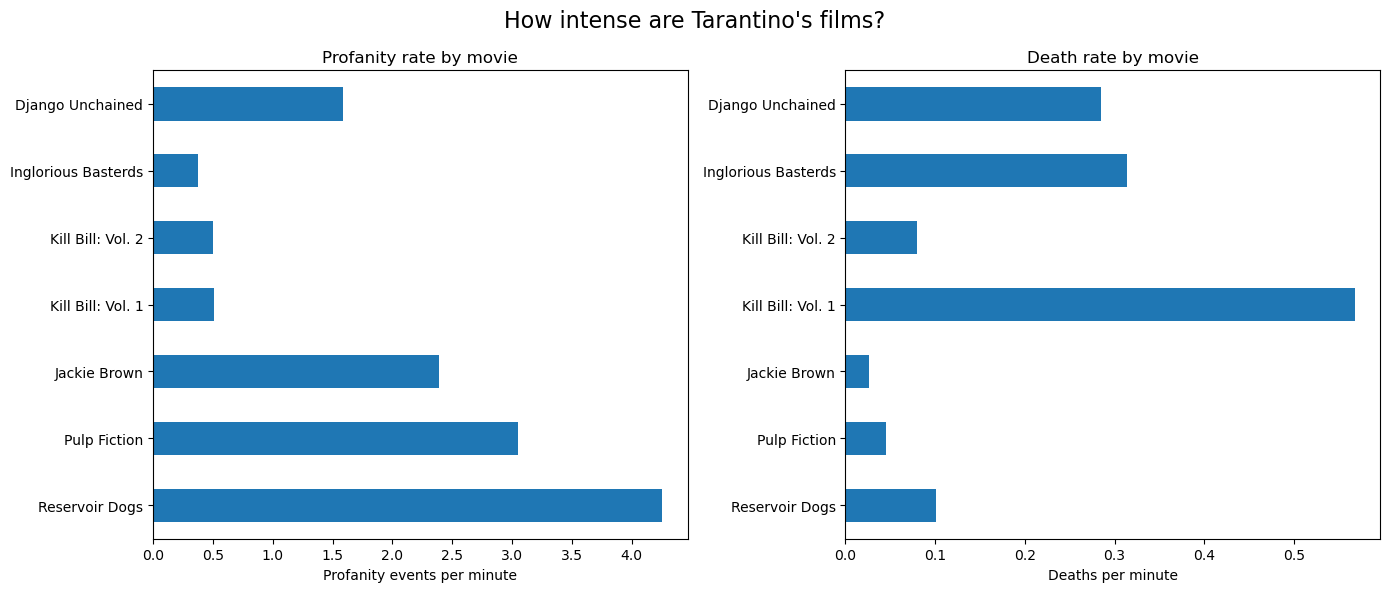

In [6]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6),
)

summary["profanity_per_min"].plot.barh(
    ax=axes[0],
)

axes[0].set_title("Profanity rate by movie")
axes[0].set_xlabel("Profanity events per minute")
axes[0].set_ylabel("")

summary["deaths_per_min"].plot.barh(
    ax=axes[1],
)

axes[1].set_title("Death rate by movie")
axes[1].set_xlabel("Deaths per minute")
axes[1].set_ylabel("")

fig.suptitle(
    "How intense are Tarantino's films?",
    fontsize=16,
)

fig.tight_layout()

fig.savefig(
    out / "01_normalized_intensity.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()


## 2. Normalized event timeline

Each event is positioned according to its percentage of movie runtime. This makes the timing comparable across films of different lengths.

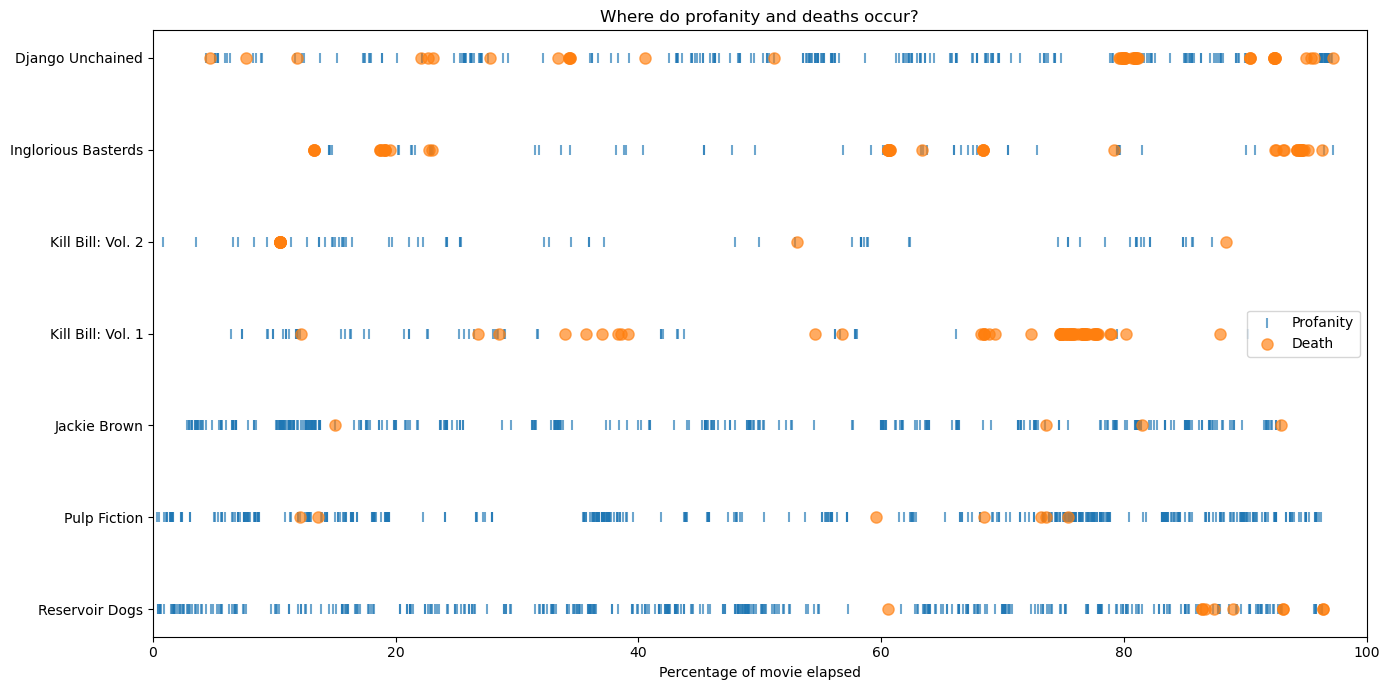

In [7]:
plot_events = events.copy()

plot_events["pct_movie"] = (
    plot_events["minutes_in"]
    / plot_events["movie"].map(
        movies.set_index("movie")["runtime"]
    )
    * 100
)

y_positions = {
    movie: i
    for i, movie in enumerate(movie_order)
}

fig, ax = plt.subplots(
    figsize=(14, 7),
)

for event_type, marker in [
    ("word", "|"),
    ("death", "o"),
]:
    subset = plot_events[
        plot_events["type"] == event_type
    ]

    ax.scatter(
        subset["pct_movie"],
        subset["movie"].map(y_positions),
        marker=marker,
        s=45 if event_type == "word" else 65,
        alpha=0.65,
        label=(
            "Profanity"
            if event_type == "word"
            else "Death"
        ),
    )

ax.set_yticks(range(len(movie_order)))
ax.set_yticklabels(movie_order)
ax.set_xlabel("Percentage of movie elapsed")
ax.set_ylabel("")
ax.set_title(
    "Where do profanity and deaths occur?"
)
ax.set_xlim(0, 100)
ax.legend()

fig.tight_layout()

fig.savefig(
    out / "02_normalized_event_timeline.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()


## 3. Event density through each movie

Each movie is divided into ten equal sections. This shows whether profanity and deaths follow similar narrative rhythms.

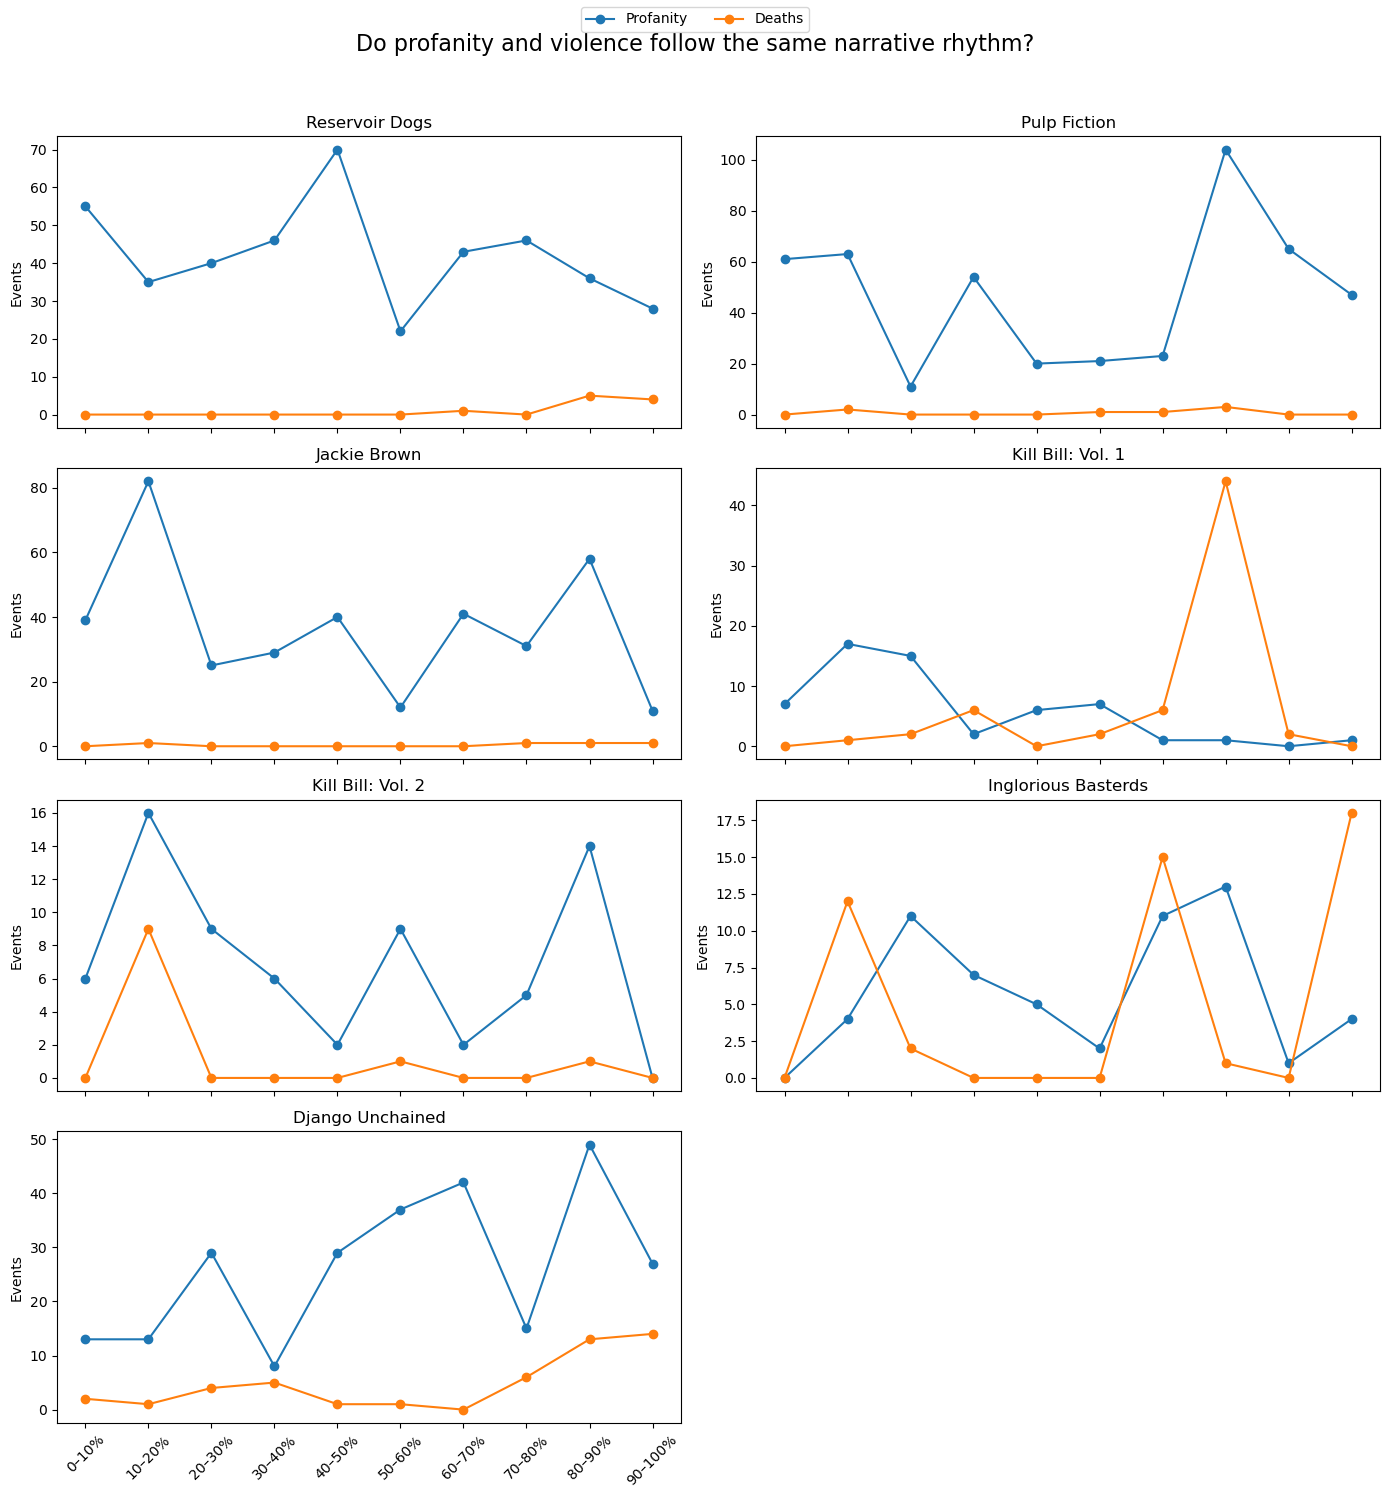

In [8]:
plot_events["movie_progress"] = (
    plot_events["pct_movie"]
    .clip(0, 100)
    .floordiv(10)
    .astype(int)
)

density = (
    plot_events
    .groupby(["movie", "movie_progress", "type"])
    .size()
    .unstack(fill_value=0)
    .reindex(
        pd.MultiIndex.from_product(
            [movie_order, range(10)],
            names=["movie", "movie_progress"],
        ),
        fill_value=0,
    )
    .reset_index()
)

fig, axes = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(14, 15),
    sharex=True,
    sharey=False,
)

axes = axes.flatten()

for ax, movie in zip(axes, movie_order):
    d = density[
        density["movie"] == movie
    ]

    x = np.arange(10)

    profanity = (
        d.set_index("movie_progress")["word"]
        .reindex(range(10), fill_value=0)
    )

    deaths = (
        d.set_index("movie_progress")["death"]
        .reindex(range(10), fill_value=0)
    )

    ax.plot(
        x,
        profanity,
        marker="o",
        label="Profanity",
    )

    ax.plot(
        x,
        deaths,
        marker="o",
        label="Deaths",
    )

    ax.set_title(movie)
    ax.set_xticks(x)
    ax.set_xticklabels(
        [
            f"{i * 10}–{(i + 1) * 10}%"
            for i in x
        ],
        rotation=45,
    )
    ax.set_ylabel("Events")

# There are seven movies, so hide the unused eighth subplot.
for ax in axes[len(movie_order):]:
    ax.set_visible(False)

handles, labels = (
    axes[0].get_legend_handles_labels()
)

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
)

fig.suptitle(
    "Do profanity and violence follow the same narrative rhythm?",
    fontsize=16,
)

fig.tight_layout(
    rect=[0, 0, 1, 0.96]
)

fig.savefig(
    out / "03_event_density.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()


## 4. Profanity vs. deaths

Each point represents a ten-minute interval. The plot tests whether more profanity tends to coincide with more deaths.

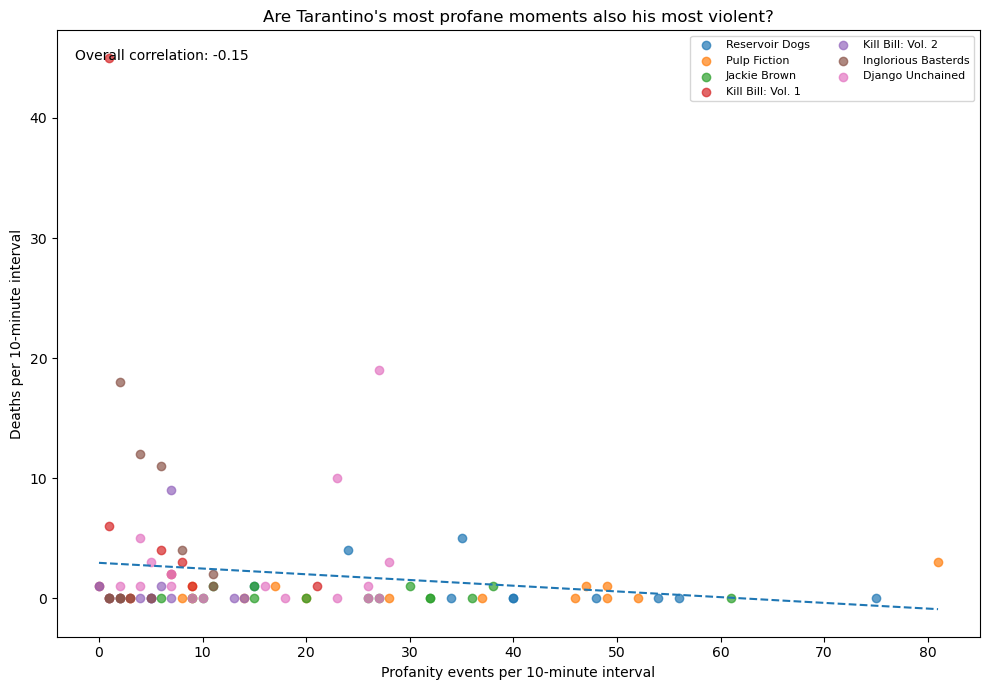

In [9]:
intervals = events.copy()

intervals["interval"] = (
    intervals["minutes_in"] // 10
).astype(int)

scatter_data = (
    intervals
    .groupby(["movie", "interval", "type"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

if "word" not in scatter_data:
    scatter_data["word"] = 0

if "death" not in scatter_data:
    scatter_data["death"] = 0

fig, ax = plt.subplots(
    figsize=(10, 7),
)

for movie in movie_order:
    subset = scatter_data[
        scatter_data["movie"] == movie
    ]

    ax.scatter(
        subset["word"],
        subset["death"],
        alpha=0.7,
        label=movie,
    )

x = scatter_data["word"].to_numpy()
y = scatter_data["death"].to_numpy()

if len(x) > 1 and np.std(x) > 0:
    slope, intercept = np.polyfit(
        x,
        y,
        1,
    )

    x_line = np.linspace(
        x.min(),
        x.max(),
        100,
    )

    ax.plot(
        x_line,
        slope * x_line + intercept,
        linestyle="--",
    )

    correlation = np.corrcoef(x, y)[0, 1]

    ax.text(
        0.02,
        0.97,
        f"Overall correlation: {correlation:.2f}",
        transform=ax.transAxes,
        va="top",
    )

ax.set_xlabel(
    "Profanity events per 10-minute interval"
)

ax.set_ylabel(
    "Deaths per 10-minute interval"
)

ax.set_title(
    "Are Tarantino's most profane moments also his most violent?"
)

ax.legend(
    fontsize=8,
    ncol=2,
)

fig.tight_layout()

fig.savefig(
    out / "04_profanity_vs_deaths.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()


## 5. Tarantino intensity fingerprint

The three metrics are standardized as z-scores so they can be compared on the same scale. Positive values are above the seven-film average; negative values are below it.

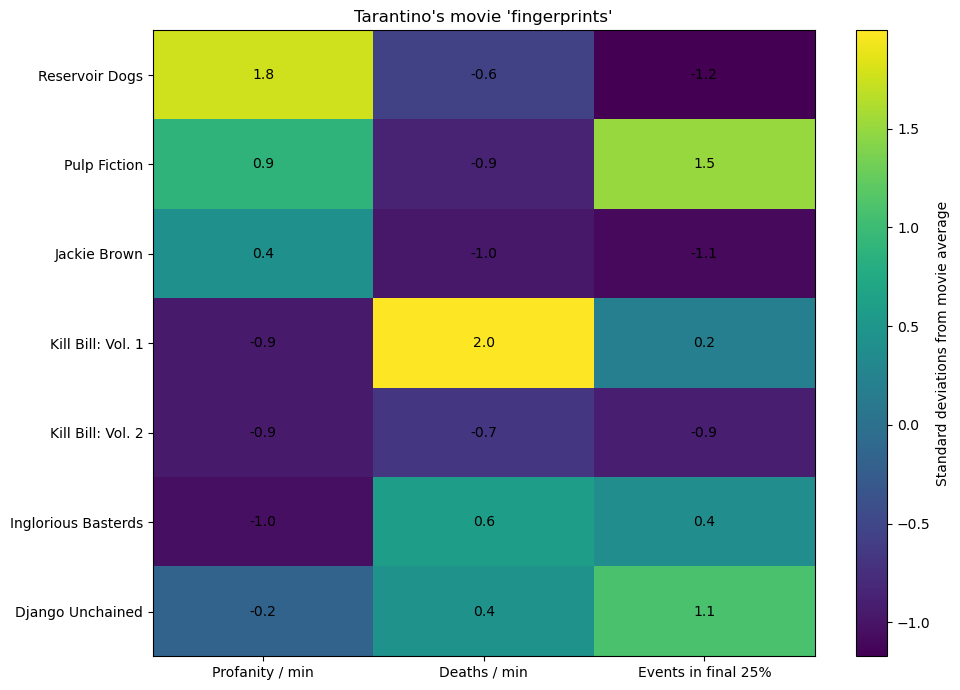

In [10]:
fingerprint = summary[
    [
        "profanity_per_min",
        "deaths_per_min",
    ]
].copy()

plot_events["final_quarter"] = (
    plot_events["pct_movie"] >= 75
)

final_quarter = (
    plot_events
    .groupby("movie")["final_quarter"]
    .mean()
    .reindex(movie_order)
)

fingerprint["events_in_final_25pct"] = (
    final_quarter
)

z = (
    fingerprint - fingerprint.mean()
) / fingerprint.std(ddof=0)

fig, ax = plt.subplots(
    figsize=(10, 7),
)

im = ax.imshow(
    z.to_numpy(),
    aspect="auto",
)

ax.set_xticks(range(len(z.columns)))
ax.set_xticklabels([
    "Profanity / min",
    "Deaths / min",
    "Events in final 25%",
])

ax.set_yticks(range(len(movie_order)))
ax.set_yticklabels(movie_order)

for i in range(z.shape[0]):
    for j in range(z.shape[1]):
        ax.text(
            j,
            i,
            f"{z.iloc[i, j]:.1f}",
            ha="center",
            va="center",
        )

ax.set_title(
    "Tarantino's movie 'fingerprints'"
)

fig.colorbar(
    im,
    ax=ax,
    label="Standard deviations from movie average",
)

fig.tight_layout()

fig.savefig(
    out / "05_tarantino_fingerprint.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()


## Export the calculated summary

In [ ]:
summary.to_csv(
    out / "movie_intensity_summary.csv"
)

print(
    f"Saved summary to: "
    f"{out / 'movie_intensity_summary.csv'}"
)
